In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal # Annotated adds extra metadata
from langchain_openai import ChatOpenAI
from pydantic import BaseModel

In [11]:
# twitter post generator
class State(TypedDict):
    topic:str
    content: str
    reties: int
    feedback: str
    status: str
    max_retries: int

In [5]:
llm = ChatOpenAI()

In [10]:
class EvaluationSchema(BaseModel):
    evaluation:Literal["approved","need_improvement"]
    feedback: str

In [22]:
def generate_topic(state:State):
    prompt=f"You are smart twitter post generator. It should be funny, not posted before and not sexual content. Use next topic for post. Topic: {state['topic']}"
    
    res = llm.invoke(prompt)
    
    return {"content":res.content}

def evaluate(state:State):
    prompt=f"You are twitter post evaluator. Evaluate post based on uniqueness, how much funny etc. Use content of post as next: {state["content"]}"
    res = llm.with_structured_output(EvaluationSchema).invoke(prompt).model_dump()
    
    return {"feedback":res["feedback"], "status":res["evaluation"]}

def optimize_content(state:State):
    prompt=f"You are twitter post optimizer. optimize post based on feedback: {state["feedback"]} and topic:{state['topic']}"
    res = llm.invoke(prompt)
    
    return {"content":res.content, "reties":state['reties']+1}

def route_evaluation(state:State):
    if(state['status'] == 'approved' or state['reties'] >= state['max_retries']):
        return 'approved'
    else: return 'need_improvement'
    


In [13]:
graph = StateGraph(State)

graph.add_node("generate_topic", generate_topic)
graph.add_node("evaluate", evaluate)
graph.add_node("optimize_content", optimize_content)

graph.add_edge(START, "generate_topic")
graph.add_edge("generate_topic", "evaluate")
graph.add_conditional_edges("evaluate", route_evaluation, {"approved":END, "need_improvement":"optimize_content"})
graph.add_edge("optimize_content", "evaluate")

workflow = graph.compile()

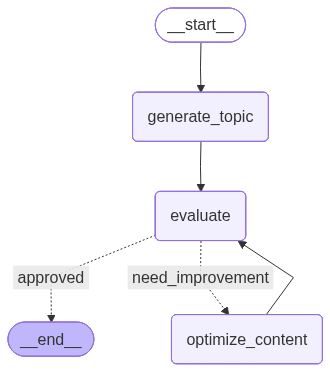

In [14]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [23]:
workflow.invoke({"topic":"hashsj"})

TypeError: 'EvaluationSchema' object is not subscriptable